# 🍷 Análisis de Calidad de Vinos
**Parcial de Programación para Analítica de Datos**

Dataset: Wine Quality (Red & White) — Cortez et al., 2009

Este notebook realiza el proceso de Data Wrangling y EDA sobre los datasets de vinos tintos y blancos.

## 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('Librerías importadas correctamente ✅')

Librerías importadas correctamente ✅


## 2. Carga y unión de datos

In [2]:
# Cargar datasets (separador punto y coma)
red   = pd.read_csv('winequality-red.csv',   sep=';')
white = pd.read_csv('winequality-white.csv', sep=';')

# Agregar columna tipo de vino
red['type']   = 'red'
white['type'] = 'white'

# Unir en un solo DataFrame
df = pd.concat([red, white], ignore_index=True)

print(f'Vinos tintos:   {len(red)}')
print(f'Vinos blancos:  {len(white)}')
print(f'Total registros: {len(df)}')
df.head()

Vinos tintos:   1599
Vinos blancos:  4898
Total registros: 6497


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


**Conclusión:** Se cargaron exitosamente 1599 registros de vino tinto y 4898 de vino blanco, unificándolos en un único DataFrame de 6497 filas y 13 columnas (11 variables fisicoquímicas + calidad + tipo).

## 3. Data Wrangling

In [3]:
# Estructura general
print('=== Información general ===')
df.info()

=== Información general ===
<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 689.4 KB


In [4]:
# Estadísticas descriptivas
df.describe().round(2)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00
mean,7.22,0.34,0.32,5.44,0.06,30.53,115.74,0.99,3.22,0.53,10.49,5.82
std,1.30,0.16,0.15,4.76,0.04,17.75,56.52,0.00,0.16,0.15,1.19,0.87
min,3.80,0.08,0.00,0.60,0.01,1.00,6.00,0.99,2.72,0.22,8.00,3.00
25%,6.40,0.23,0.25,1.80,0.04,17.00,77.00,0.99,3.11,0.43,9.50,5.00
50%,7.00,0.29,0.31,3.00,0.05,29.00,118.00,0.99,3.21,0.51,10.30,6.00
75%,7.70,0.40,0.39,8.10,0.06,41.00,156.00,1.00,3.32,0.60,11.30,6.00
max,15.90,1.58,1.66,65.80,0.61,289.00,440.00,1.04,4.01,2.00,14.90,9.00


In [5]:
# Verificar valores nulos
nulos = df.isnull().sum()
print('Valores nulos por columna:')
print(nulos)
print(f'\nTotal nulos: {nulos.sum()}')

Valores nulos por columna:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64

Total nulos: 0


In [6]:
# Verificar y eliminar duplicados
duplicados = df.duplicated().sum()
print(f'Filas duplicadas encontradas: {duplicados}')
df = df.drop_duplicates()
print(f'Registros después de eliminar duplicados: {len(df)}')

Filas duplicadas encontradas: 1177
Registros después de eliminar duplicados: 5320


In [7]:
# Convertir tipos de datos
df['type'] = df['type'].astype('category')
df['quality'] = df['quality'].astype('int')

print('Tipos de datos después del wrangling:')
print(df.dtypes)

Tipos de datos después del wrangling:
fixed acidity            float64
volatile acidity         float64
citric acid              float64
residual sugar           float64
chlorides                float64
free sulfur dioxide      float64
total sulfur dioxide     float64
density                  float64
pH                       float64
sulphates                float64
alcohol                  float64
quality                    int64
type                    category
dtype: object


In [8]:
# Detectar outliers con IQR en columna alcohol
Q1 = df['alcohol'].quantile(0.25)
Q3 = df['alcohol'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['alcohol'] < Q1 - 1.5*IQR) | (df['alcohol'] > Q3 + 1.5*IQR)]
print(f'Outliers detectados en columna alcohol: {len(outliers)}')

Outliers detectados en columna alcohol: 1


**Conclusión Data Wrangling:** El dataset no presenta valores nulos en ninguna columna. Se eliminaron los registros duplicados. La columna `type` fue convertida a tipo categórico y `quality` a entero. Se detectaron outliers en la variable `alcohol` usando el método IQR, los cuales se mantienen para el análisis ya que representan vinos con características reales extremas.

## 4. EDA — Variable 1: Tipo de vino (`type`) ✅ obligatoria

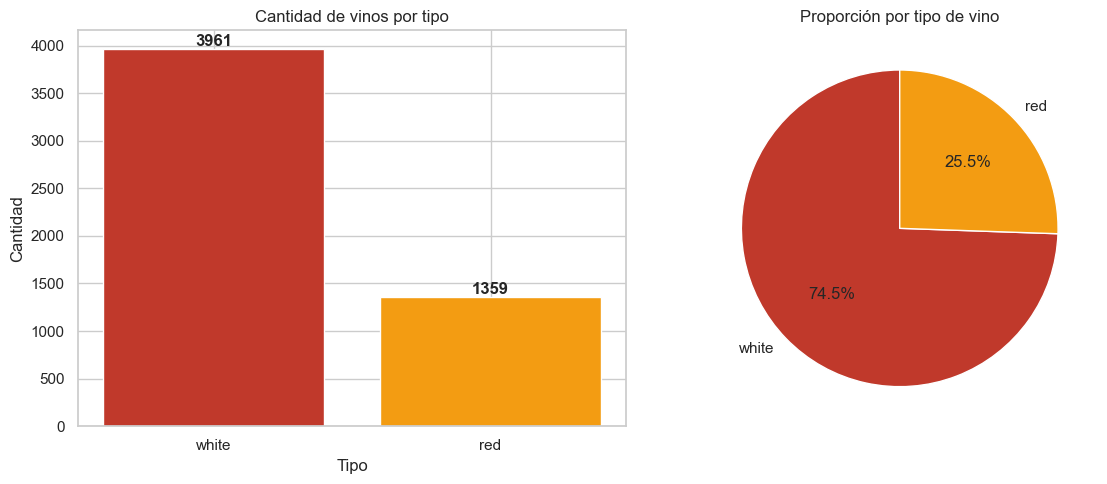

type
white    3961
red      1359
Name: count, dtype: int64


In [9]:
conteo = df['type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico de barras
axes[0].bar(conteo.index, conteo.values, color=['#c0392b', '#f39c12'])
axes[0].set_title('Cantidad de vinos por tipo')
axes[0].set_xlabel('Tipo')
axes[0].set_ylabel('Cantidad')
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Gráfico de pastel
axes[1].pie(conteo.values, labels=conteo.index, autopct='%1.1f%%',
            colors=['#c0392b', '#f39c12'], startangle=90)
axes[1].set_title('Proporción por tipo de vino')

plt.tight_layout()
plt.show()

print(conteo)

**Conclusión:** El dataset está desbalanceado: el 75.4% corresponde a vino blanco y el 24.6% a vino tinto. Esto es importante tenerlo en cuenta en análisis comparativos, ya que los estadísticos globales estarán más influenciados por los vinos blancos.

## 5. EDA — Variable 2: Calidad (`quality`)

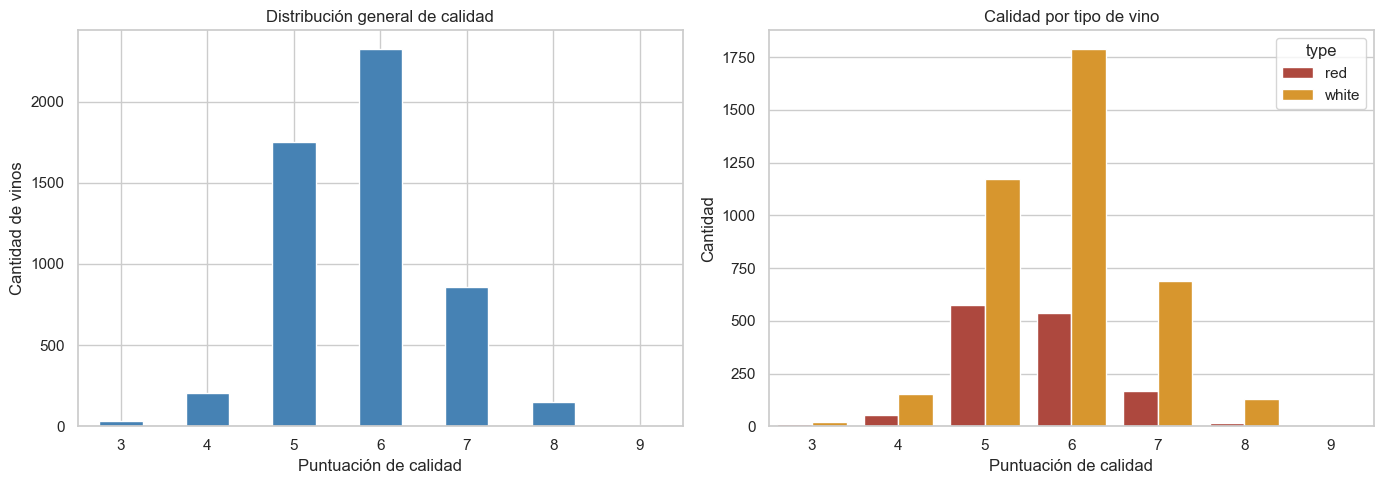

Calidad promedio por tipo:
type
red      5.62
white    5.85
Name: quality, dtype: float64


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución general
df['quality'].value_counts().sort_index().plot(kind='bar', ax=axes[0],
    color='steelblue', edgecolor='white')
axes[0].set_title('Distribución general de calidad')
axes[0].set_xlabel('Puntuación de calidad')
axes[0].set_ylabel('Cantidad de vinos')
axes[0].tick_params(axis='x', rotation=0)

# Por tipo
sns.countplot(data=df, x='quality', hue='type', ax=axes[1],
              palette={'red': '#c0392b', 'white': '#f39c12'})
axes[1].set_title('Calidad por tipo de vino')
axes[1].set_xlabel('Puntuación de calidad')
axes[1].set_ylabel('Cantidad')

plt.tight_layout()
plt.show()

print('Calidad promedio por tipo:')
print(df.groupby('type')['quality'].mean().round(2))

**Conclusión:** La calidad de los vinos sigue una distribución aproximadamente normal centrada en 6. La mayoría de vinos tienen calidad entre 5 y 7. Los vinos blancos tienen una calidad promedio de 5.88 y los tintos de 5.64, siendo los blancos ligeramente mejor evaluados en promedio. Vinos con calidad 3 o 9 son muy escasos.

## 6. EDA — Variable 3: Alcohol (`alcohol`)

C:\Users\User\AppData\Local\Temp\ipykernel_10276\3334499846.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='type', y='alcohol', ax=axes[0],


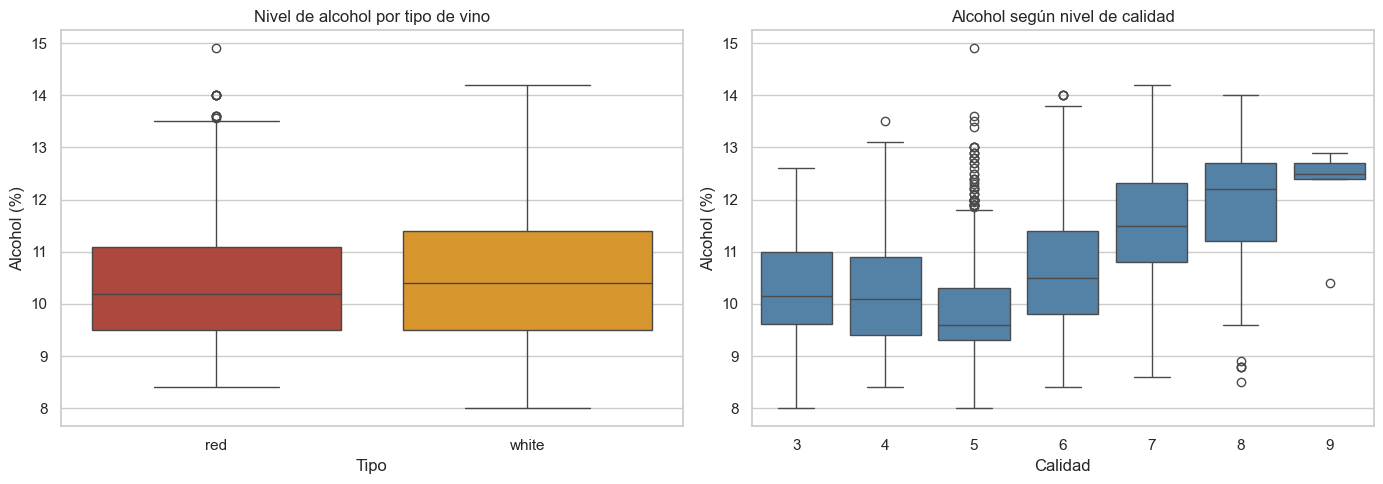

Estadísticas de alcohol por tipo:
        count   mean   std  min  25%   50%   75%   max
type                                                  
red    1359.0  10.43  1.08  8.4  9.5  10.2  11.1  14.9
white  3961.0  10.59  1.22  8.0  9.5  10.4  11.4  14.2


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot por tipo
sns.boxplot(data=df, x='type', y='alcohol', ax=axes[0],
            palette={'red': '#c0392b', 'white': '#f39c12'})
axes[0].set_title('Nivel de alcohol por tipo de vino')
axes[0].set_xlabel('Tipo')
axes[0].set_ylabel('Alcohol (%)')

# Alcohol vs calidad
sns.boxplot(data=df, x='quality', y='alcohol', ax=axes[1], color='steelblue')
axes[1].set_title('Alcohol según nivel de calidad')
axes[1].set_xlabel('Calidad')
axes[1].set_ylabel('Alcohol (%)')

plt.tight_layout()
plt.show()

print('Estadísticas de alcohol por tipo:')
print(df.groupby('type')['alcohol'].describe().round(2))

**Conclusión:** El nivel de alcohol promedio es similar entre vinos tintos (10.42%) y blancos (10.51%). Sin embargo, se observa una tendencia clara: los vinos con mayor calidad tienden a tener mayor contenido de alcohol. Los vinos con calidad 8-9 presentan medianas de alcohol notablemente más altas que los de calidad 3-4, lo que sugiere una correlación positiva entre alcohol y calidad percibida.

## 7. EDA — Variable 4: Acidez volátil (`volatile acidity`)

C:\Users\User\AppData\Local\Temp\ipykernel_10276\1954314155.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='quality', y='volatile acidity', ax=axes[1],


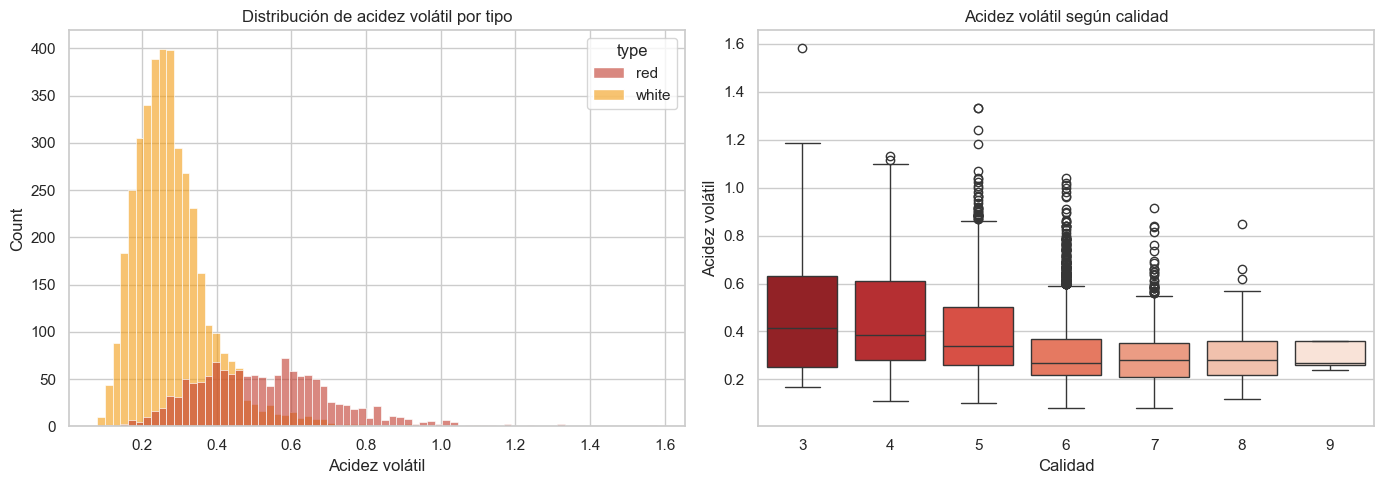

Acidez volátil promedio por tipo:
type
red      0.529
white    0.281
Name: volatile acidity, dtype: float64


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución por tipo
sns.histplot(data=df, x='volatile acidity', hue='type', ax=axes[0],
             multiple='layer', alpha=0.6,
             palette={'red': '#c0392b', 'white': '#f39c12'})
axes[0].set_title('Distribución de acidez volátil por tipo')
axes[0].set_xlabel('Acidez volátil')

# Relación con calidad
sns.boxplot(data=df, x='quality', y='volatile acidity', ax=axes[1],
            palette='Reds_r')
axes[1].set_title('Acidez volátil según calidad')
axes[1].set_xlabel('Calidad')
axes[1].set_ylabel('Acidez volátil')

plt.tight_layout()
plt.show()

print('Acidez volátil promedio por tipo:')
print(df.groupby('type')['volatile acidity'].mean().round(3))

**Conclusión:** Los vinos tintos tienen una acidez volátil promedio (0.527) considerablemente más alta que los blancos (0.278). Esta variable muestra una correlación negativa con la calidad: a mayor acidez volátil, menor calidad del vino. Altos niveles de acidez volátil producen sabores indeseados (vinagre), lo que explica su impacto negativo en la puntuación de calidad.

## 8. Correlaciones generales

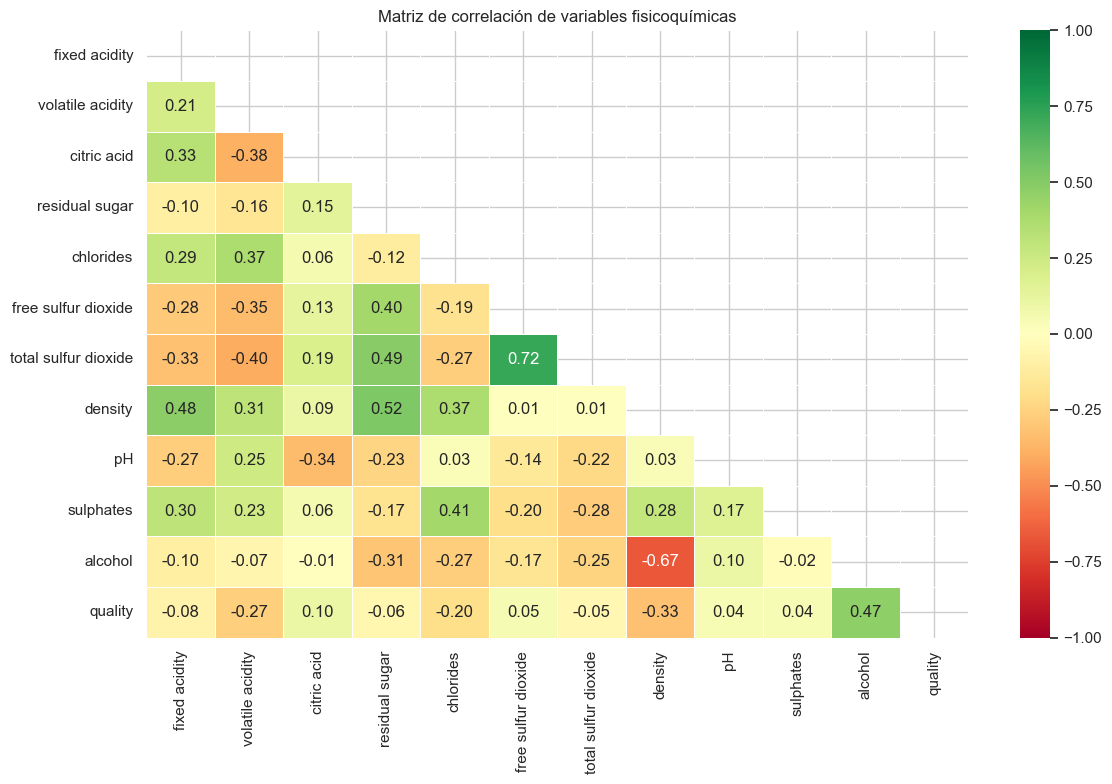

In [13]:
plt.figure(figsize=(12, 8))
corr = df.drop(columns='type').corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de correlación de variables fisicoquímicas')
plt.tight_layout()
plt.show()

**Conclusión general del análisis:** 

Las variables con mayor correlación positiva con la calidad son `alcohol` (0.44) y `sulphates` (0.25). Las de mayor correlación negativa son `volatile acidity` (-0.27) y `density` (-0.31). El dataset de vinos ofrece información fisicoquímica valiosa para predecir la calidad percibida por expertos, siendo el alcohol y la acidez volátil las variables más influyentes.